<a href="https://colab.research.google.com/github/Nirucoder/SRM_INSIDER/blob/main/insider.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **My first ml project**

LR MSE(Train): 1.0075362951093687
LR R2(Train): 0.7645051774663391
LR MSE(Test): 1.0206953660861033
LR R2(Test): 0.7891616188563282


Text(0.5, 0, 'Real Values')

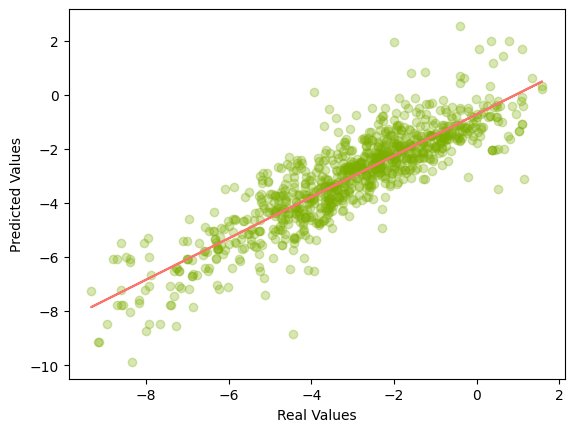

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
df=pd.read_csv(' https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv')
y= df['logS']
X=df.drop('logS',axis=1)
#Data splitting
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)
X_train
#linear Regression
lr=LinearRegression()
lr.fit(X_train,y_train)
#Applying the model to make a prediction
y_lr_train_pred=lr.predict(X_train)
y_lr_test_pred=lr.predict(X_test)
y_lr_train_pred
#Evaluate Model Performance
from sklearn.metrics import mean_squared_error,r2_score
lr_train_mse=mean_squared_error(y_train,y_lr_train_pred)
lr_train_r2=r2_score(y_train,y_lr_train_pred)
lr_test_mse=mean_squared_error(y_test,y_lr_test_pred)
lr_test_r2=r2_score(y_test,y_lr_test_pred)
print('LR MSE(Train):',lr_train_mse)
print('LR R2(Train):',lr_train_r2)
print('LR MSE(Test):',lr_test_mse)
print('LR R2(Test):',lr_test_r2)
lr_results=pd.DataFrame(['Linear Regression',lr_train_mse,lr_train_r2,lr_test_mse,lr_test_r2]).transpose()
lr_results.columns=['Method','Training MSE','Training R2','Test_Mse','Test_R2']
lr_results
#Random Forest
from sklearn.ensemble import RandomForestRegressor
#Training the model
rf=RandomForestRegressor(max_depth=2,random_state=100)
rf.fit(X_train,y_train)
#Applying the model to make a prediction
y_rf_train_pred=rf.predict(X_train)
y_rf_test_pred=rf.predict(X_test)
#Evaluate Model Performance
rf_train_mse=mean_squared_error(y_train,y_rf_train_pred)
rf_train_r2=r2_score(y_train,y_rf_train_pred)
rf_test_mse=mean_squared_error(y_test,y_rf_test_pred)
rf_test_r2=r2_score(y_test,y_rf_test_pred)
rf_results=pd.DataFrame(['Random Forest',rf_train_mse,rf_train_r2,rf_test_mse,rf_test_r2]).transpose()
rf_results.columns=['Method','Training MSE','Training R2','Test_Mse','Test_R2']
rf_results
#Model comparison
df_models=pd.concat([lr_results,rf_results],axis=0)
df_models
df_models.reset_index(drop=True)
#Data visualization of prediction results
import matplotlib.pyplot as plt
plt.scatter(x=y_train,y=y_lr_train_pred,c="#7CAE00",alpha=0.3)
z=np.polyfit(y_train,y_lr_train_pred,1)
p=np.poly1d(z)
plt.plot(y_train,p(y_train),'#F8766D')
plt.ylabel('Predicted Values')
plt.xlabel('Real Values')